In [1]:
import pandas as pd
import pathlib
import rootutils
import torch

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
root = pathlib.Path(rootutils.find_root("."))

from matplotlib import pyplot as plt
from matplotlib import patches

from src.core.data.sounding_out_chorus import SoundingOutChorus
from src.core.models.vae import VAE
from src.core.models.sivae import SIVAE
from src.core.evaluators.translation_invariance_figure import designal
from src.core.transforms.translation import translation_1d as translation

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [2]:
checkpoint_dir = pathlib.Path("/its/home/kag25/models/v1/")
model_name = "vae/misty-lecture/"
checkpoint_path = "step=180000.ckpt"
vae = VAE.load_from_checkpoint(checkpoint_dir / model_name / checkpoint_path, map_location="cpu")

checkpoint_dir = pathlib.Path("/its/home/kag25/models/v1/")
model_name = "sivae/mossy-andrea/"
checkpoint_path = "step=180000.ckpt"
sivae = SIVAE.load_from_checkpoint(checkpoint_dir / model_name / checkpoint_path, map_location="cpu")

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

In [3]:
data = SoundingOutChorus("/its/home/kag25/data/sounding_out")
metadata = data.metadata
file_name = "KN-10_1_20150508_0600.wav"
record = metadata[metadata.file_name == file_name].iloc[0]
file_path = record.file_path

In [4]:
wav = data.load_sample(file_path)
x = vae.pre_process(wav.unsqueeze(0)).squeeze()

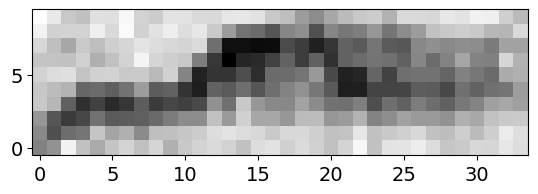

In [5]:
bbox = [2530, 2564, 20, 30]
t_i, t_j, f_i, f_j = bbox
signal = x[t_i:t_j, f_i:f_j]
s = signal.size(0)
plt.imshow(signal.T, origin="lower", cmap="Greys")

In [6]:
x_bg = designal(x)[:192]
t_start = (x_bg.size(0)) // 2
x_bg[t_start-s//2:t_start+s//2, f_i:f_j] = signal

In [7]:
xs = []
deltas = torch.linspace(-1.0, 1.0, 9)
for i, delta in enumerate(deltas):
    x_trans = translation(x_bg.transpose(-1, -2).unsqueeze(0).unsqueeze(0), delta).squeeze().transpose(-1, -2)
    xs.append(x_trans)
xs = torch.stack(xs).unsqueeze(1)
xs.shape, deltas

(torch.Size([9, 1, 192, 64]),
 tensor([-1.0000, -0.7500, -0.5000, -0.2500,  0.0000,  0.2500,  0.5000,  0.7500,
          1.0000]))

In [8]:
with torch.no_grad():
    _, us = vae.feature_encoder(xs)

In [9]:
us[0].shape, us[1].shape, us[2].shape, us[3].shape

(torch.Size([9, 32, 96, 64]),
 torch.Size([9, 64, 48, 32]),
 torch.Size([9, 128, 24, 16]),
 torch.Size([9, 256, 12, 8]))

In [10]:
us[0].shape[1]

32

/tmp/ipykernel_3100618/1417573864.py:2: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3697.)
  plt.imshow(xs[4].T, origin="lower", cmap="Greys", aspect="auto")


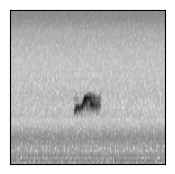

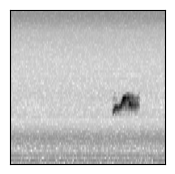

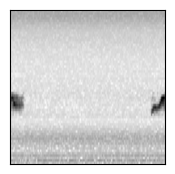

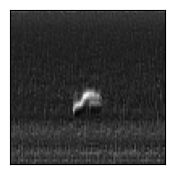

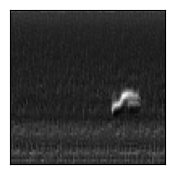

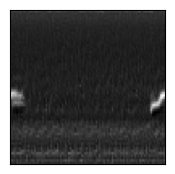

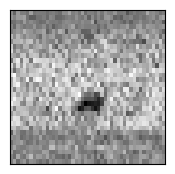

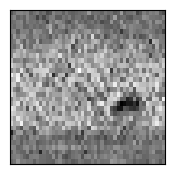

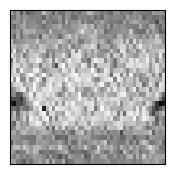

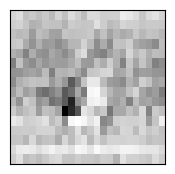

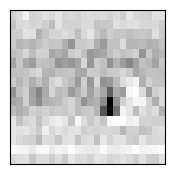

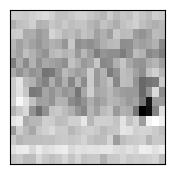

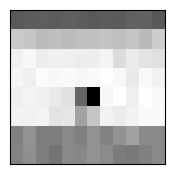

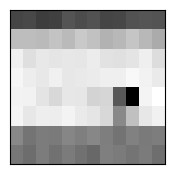

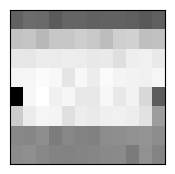

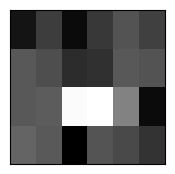

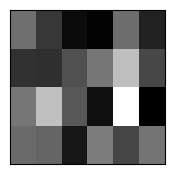

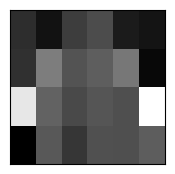

In [11]:
plt.figure(figsize=(2, 2))
plt.imshow(xs[4].T, origin="lower", cmap="Greys", aspect="auto")
plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
plt.show()

plt.figure(figsize=(2, 2))
plt.imshow(xs[2].T, origin="lower", cmap="Greys", aspect="auto")
plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
plt.show()

plt.figure(figsize=(2, 2))
plt.imshow(xs[0].T, origin="lower", cmap="Greys", aspect="auto")
plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
plt.show()

for i in range(5):
    u = us[i]
    plt.figure(figsize=(2, 2))
    plt.imshow(u[4][0].T, origin="lower", cmap="Greys", aspect="auto")
    plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    plt.show()
    
    plt.figure(figsize=(2, 2))
    plt.imshow(u[2][0].T, origin="lower", cmap="Greys", aspect="auto")
    plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    plt.show()

    plt.figure(figsize=(2, 2))
    plt.imshow(u[0][0].T, origin="lower", cmap="Greys", aspect="auto")
    plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    plt.show()



2026-05-15 17:34:17.344932: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-15 17:34:17.361952: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-15 17:34:17.361972: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-15 17:34:17.362827: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-15 17:34:17.366820: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructio

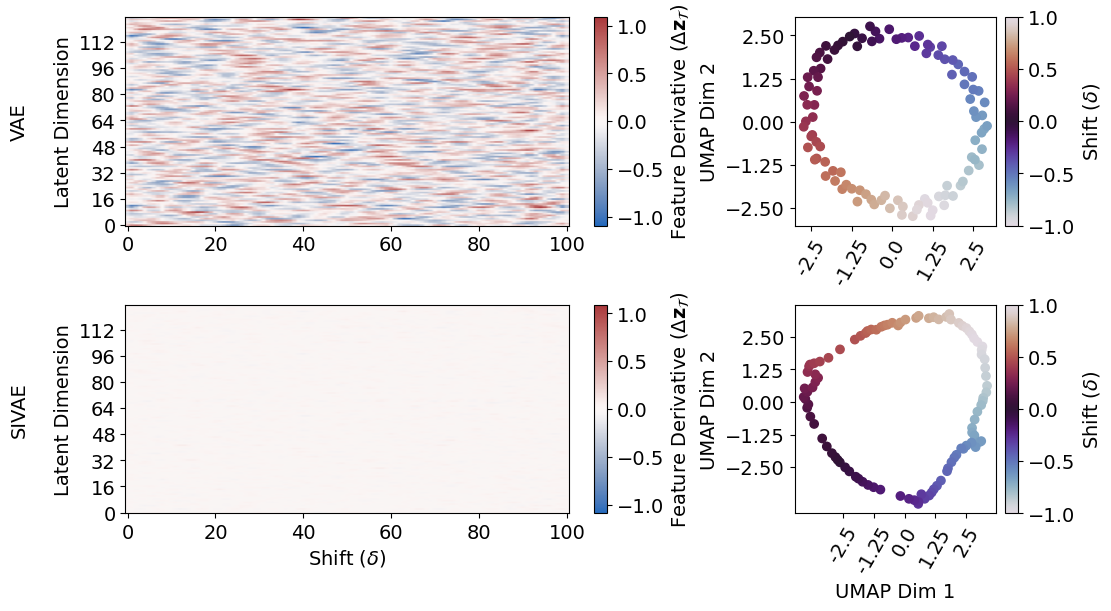

In [8]:
import numpy as np
import seaborn as sns
from umap import UMAP
from torch.functional import F

plt.rcParams.update({
    'font.size': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

fig, axes = plt.subplots(nrows=2, ncols=4, width_ratios=[0.66, 0.02, 0.3, 0.02], figsize=(11, 6), constrained_layout=True)

checkpoint_dir = pathlib.Path("/its/home/kag25/models/v1/")
model_name = "vae/misty-lecture/"
checkpoint_path = "step=180000.ckpt"
vae = VAE.load_from_checkpoint(checkpoint_dir / model_name / checkpoint_path, map_location="cpu").eval()

sivae = SIVAE.load_from_checkpoint(root / "sivae.ckpt", map_location="cpu").eval()

def central_finite_difference(x, padding_mode="circular"):
    x = F.pad(x, (1, 1), padding_mode)
    kernel = torch.tensor([[[-1.0, 0.0, 1.0]]]).to(x.device)
    dxdt = F.conv1d(x.unsqueeze(-2), kernel).squeeze(-2)
    return dxdt

xs = []
deltas = torch.linspace(-1.0, 1.0, 101)
for i, delta in enumerate(deltas):
    x_trans = translation(x_bg.transpose(-1, -2).unsqueeze(0).unsqueeze(0), delta).squeeze().transpose(-1, -2)
    xs.append(x_trans)
xs = torch.stack(xs).unsqueeze(1)
with torch.no_grad():
    q_z, *_ = vae.encode(xs)
mu_z, _ = q_z.chunk(2, dim=-1)
dzdT = central_finite_difference(mu_z.squeeze(1).t())
bound = max(dzdT.max().abs(), dzdT.min().abs())
im = axes[0, 0].imshow(dzdT, vmin=-bound, vmax=bound, cmap=sns.color_palette("vlag", as_cmap=True), origin="lower", aspect="auto")
cbar = fig.colorbar(im, cax=axes[0, 1])
cbar.set_label("Feature Derivative ($\Delta \mathbf{z}_{\mathcal{T}}$)")
# axes[0, 0].set_xlabel("Shift ($\delta$)")
axes[0, 0].set_ylabel("VAE\n\nLatent Dimension")
axes[0, 0].set_yticks(np.arange(0, 128, 16), np.arange(0, 128, 16))

np.random.seed(42)
umap = UMAP(random_state=42, n_jobs=1)
u = umap.fit_transform(mu_z.squeeze(1).numpy())
u[:, 0] = (u[:, 0]- u[:, 0].mean())
u[:, 1] = (u[:, 1]- u[:, 1].mean())
ls = axes[0, 2].scatter(u[:,0], u[:,1], c=deltas, cmap="twilight")
cbar = fig.colorbar(ls, cax=axes[0, 3])
cbar.set_label(r"Shift ($\delta$)")
axes[0, 2].set_yticks(np.linspace(-2.5, 2.5, 5))
axes[0, 2].set_xticks(np.linspace(-2.5, 2.5, 5), np.linspace(-2.5, 2.5, 5), rotation=60)
# axes[0, 2].set_xlabel("UMAP Dim 1")
axes[0, 2].set_ylabel("UMAP Dim 2")



with torch.no_grad():
    q_z, *_ = sivae.encode(xs)
mu_z, _ = q_z.chunk(2, dim=-1)
dzdT = central_finite_difference(mu_z.squeeze(1).t())
im = axes[1, 0].imshow(dzdT, vmin=-bound, vmax=bound, cmap=sns.color_palette("vlag", as_cmap=True), origin="lower", aspect="auto")
cbar = fig.colorbar(im, cax=axes[1, 1])
cbar.set_label("Feature Derivative ($\Delta \mathbf{z}_{\mathcal{T}}$)")
axes[1, 0].set_xlabel("Shift ($\delta$)")
axes[1, 0].set_ylabel("SIVAE\n\nLatent Dimension")
axes[1, 0].set_yticks(np.arange(0, 128, 16), np.arange(0, 128, 16))

np.random.seed(42)
umap = UMAP(random_state=42, n_jobs=1)
u = umap.fit_transform(mu_z.squeeze(1).numpy())
u[:, 0] = (u[:, 0]- u[:, 0].mean())
u[:, 1] = (u[:, 1]- u[:, 1].mean())
ls = axes[1, 2].scatter(u[:,0], u[:,1], c=deltas, cmap="twilight")
cbar = fig.colorbar(ls, cax=axes[1, 3])
cbar.set_label(r"Shift ($\delta$)")
axes[1, 2].set_yticks(np.linspace(-2.5, 2.5, 5))
axes[1, 2].set_xticks(np.linspace(-2.5, 2.5, 5), np.linspace(-2.5, 2.5, 5), rotation=60)
axes[1, 2].set_xlabel("UMAP Dim 1")
axes[1, 2].set_ylabel("UMAP Dim 2")

plt.show()